In [ ]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
from astropy.io import fits
%matplotlib inline



Text(0, 0.5, '$C_\\ell^{\\mathrm{g\\tau}}$')

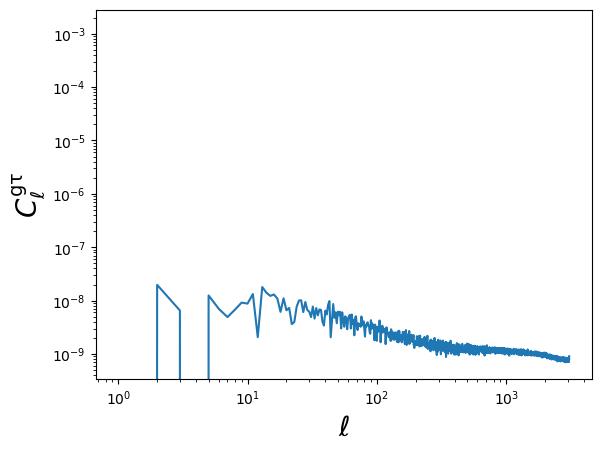

In [14]:
df = pk.load(open('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/results/mock_gen/maps_websky/RUN2_v0_tau_sim_B16_nside_1024_split_0_1.pkl','rb'))
map_ymap = df['map_ymap']
map_tau = df['map_tau']
map_ksz = df['map_ksz']


df = fits.open('/mnt/ceph/users/spandey/websky/halo_input_wM200c_zmax2p5_minM200m_4e13_new.fits')
ra_all = df[1].data['ra']
dec_all = df[1].data['dec']
z_all = df[1].data['z']
M200c_all = df[1].data['M200c_wh']
M200m_all = df[1].data['M200m_wh']
vlos_all = df[1].data['vrad']

indsel = np.where((z_all>0.2) & (z_all<0.5) & (M200m_all>6e13) & (M200m_all<5e15))[0]

ra_all = ra_all[indsel]
dec_all = dec_all[indsel]
z_all = z_all[indsel]
M200c_all = M200c_all[indsel]
M200m_all = M200m_all[indsel]
vlos_all = vlos_all[indsel]

nside = hp.get_nside(map_ymap)
map_halo = np.zeros(12 * nside**2, dtype=np.float32)
pix_halo = hp.ang2pix(nside, ra_all, dec_all, lonlat=True)
np.add.at(map_halo, pix_halo, 1.)
delta_map_halo = map_halo/np.mean(map_halo)

Cl_gy = hp.anafast(delta_map_halo, map_ymap)
Cl_gtau = hp.anafast(delta_map_halo, map_tau)
Cl_gksz = hp.anafast(delta_map_halo, map_ksz)

plt.figure()
plt.plot(np.arange(len(Cl_gtau)),Cl_gtau/(hp.pixwin(nside)**2))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{\mathrm{g\tau}}$', fontsize=20)




(5e-10, 1e-07)

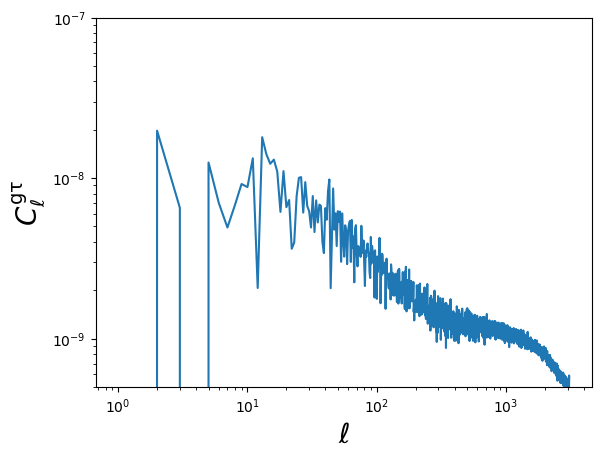

In [16]:
plt.figure()
plt.plot(np.arange(len(Cl_gtau)),Cl_gtau/(hp.pixwin(nside)))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{\mathrm{g\tau}}$', fontsize=20)
plt.ylim(5e-10, 1e-7)


